## imports

In [88]:
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist, pdist
from scipy.signal import resample
from scipy.stats import zscore
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns
%matplotlib inline


def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)


def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))


## set paths

In [2]:
ep_model_dir = '../../data/models/episodes/'
ep_traj_dir = os.path.join(ep_model_dir, 't100_w50/', 'trajectories')
ep_seg_dir = os.path.join(ep_model_dir, 't100_w50/', 'events')
ep_emb_dir = os.path.join(ep_model_dir, 't100_w50/', 'embeddings')
rec_model_dir = '../../data/models/participants/'
rec_traj_dir = os.path.join(rec_model_dir, 'trajectories')
rec_seg_dir = os.path.join(rec_model_dir, 'events', 'k:1000')
rec_emb_dir = os.path.join(rec_model_dir, 'embeddings')
pickle_dir = '../../data/pickles/'

## load data

In [84]:
# episode trajectories
episode_trajectories = {episode : np.load(os.path.join(ep_traj_dir,episode+'_model_t100_w50_res.npy')) for episode
                       in ['atlep1','atlep2','arrdev']}

# episode events
episode_events = {episode : np.load(os.path.join(ep_seg_dir,episode+'_events.npy')) 
                  for episode in ['atlep1','atlep2','arrdev']}

# individual participant trajectories
participant_trajectories = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_traj_dir, topdown=True):
    dirs[:] = [d for d in dirs if d not in ['vidwProp', 'vidwProp_recwProp']]
    traj_models = [f for f in files if f.startswith('debug') and f.endswith('.npy')]
    for f_name in traj_models:
        t = np.load(os.path.join(root,f_name))
        participant_trajectories[os.path.split(root)[-1]].append((f_name.split('.')[0],t))
        
# average participant trajectories
avg_participant_trajectories = {rectype : np.load(os.path.join(rec_traj_dir, rectype, 'avg_trajectory.npy')) for 
                               rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}


# individual participant events
participant_events = {'atlep1' : [], 'atlep2' : [], 'arrdev' : [], 'delayed': [], 'prediction' : []}

for root, dirs, files in os.walk(rec_seg_dir):
    events_models = [f for f in files if f.startswith('debug') and f.endswith('events.npy')]
    for f_name in events_models:
        m = np.load(os.path.join(root,f_name))
        participant_events[os.path.split(root)[-1]].append((f_name.split('_')[0],m))

# average participant events
avg_participant_events = {rectype : np.load(os.path.join(rec_seg_dir,rectype,'avg_events.npy')) 
                         for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']}
        
# episode-recall event mappings
event_mappings = dict()
for rectype in ['atlep1','atlep2','arrdev','delayed','prediction']:
    with open(os.path.join(rec_seg_dir,rectype,'event_mappings.p'), 'rb') as f:
        event_mappings[rectype] = pickle.load(f)
        
# session 1/session 2 psiturk ID mapppings
with open(os.path.join(pickle_dir,'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

## filter events with no predictions from average prediction events

In [85]:
no_rec_mask = np.all(np.equal(avg_pred_events, 0), axis=1)
avg_pred_events = avg_pred_events[~no_rec_mask]

## filter atlep2 recall events with no recalls from average

In [86]:
no_rec_mask = np.all(np.equal(avg_atlep2_rec_events, 0), axis=1)
avg_atlep2_rec_events = avg_atlep2_rec_events[~no_rec_mask]

## shorten some frequent variables

In [4]:
pred_trajs = participant_trajectories['prediction']
avg_pred_traj = avg_participant_trajectories['prediction']
pred_events = participant_events['prediction']
avg_pred_events = avg_participant_events['prediction']
atlep2_traj = episode_trajectories['atlep2']
atlep2_events = episode_events['atlep2']
atlep2_rec_trajs = participant_trajectories['atlep2']
avg_atlep2_rec_traj = avg_participant_trajectories['atlep2']
atlep2_rec_events = participant_events['atlep2']
avg_atlep2_rec_events = avg_participant_events['atlep2']

## does content of prediction relate to content of eventually remembered moments?

In [39]:
# for each participant who viewed atlep2
for turkid2, events in participant_events['atlep2']:
    # get their across-session study ID and session 1 psiturk ID
    sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
                        if id_maps[sid]['session 2'] == turkid2)
    
    # get their prediction and atlep2 recall trajectories
    sub_pred_traj = next(p_traj for tid, p_traj in pred_trajs if tid == turkid1)
    sub_atlep2_rec_traj = next(r_traj for tid, r_traj in atlep2_rec_trajs if tid == turkid2)
    
    tpt_pred_dist = []
    tpt_rec_dist = []
    # for each prediction timepoint
    for tpt in sub_pred_traj:
        # find closest atlep2 timepoint and its index
        mindist_p, mindist_ix = np.min(cdist([tpt],atlep2_traj)), np.argmin(cdist([tpt], atlep2_traj))
        
        # find distance from that atlep2 timepoint to nearest recall timepoint
        mindist_r = np.min(cdist([atlep2_traj[mindist_ix]], sub_atlep2_rec_traj))
        
        tpt_pred_dist.append(mindist_p)
        tpt_rec_dist.append(mindist_r)

    break


In [44]:
tpt_pred_dist

[0.41171414250412736,
 0.40269887319662667,
 0.4041475624215795,
 0.40612310977789084,
 0.4101550859377123,
 0.41697501000872955,
 0.42179419985700667,
 0.41967348143899985,
 0.41075089787306446,
 0.4000127497608487,
 0.3924307037393496,
 0.3894565739282954,
 0.38985858848341737,
 0.392560401953069,
 0.3974123349933699,
 0.4037218413384754,
 0.40979607119058303,
 0.4139870981109788,
 0.4159193465007645,
 0.4161708823961329,
 0.41552899617759337,
 0.4146521915148164,
 0.4143592055572923,
 0.415571059888479,
 0.41856254336446,
 0.4224313234521806,
 0.4256239027443681,
 0.42702051738341174,
 0.42628968999767514,
 0.4237979650242386,
 0.42025774315918174,
 0.416562618238762,
 0.41371677629149933,
 0.4124334222292201,
 0.41265338745397434,
 0.41353204836185153,
 0.4139664581920738,
 0.41316660173863845,
 0.41087906355823756,
 0.4073062506334408,
 0.4030074378443373,
 0.398749878870633,
 0.395167810563063,
 0.3926353828782845,
 0.39137423078350575,
 0.3916544851246589,
 0.3937138553333375,
 

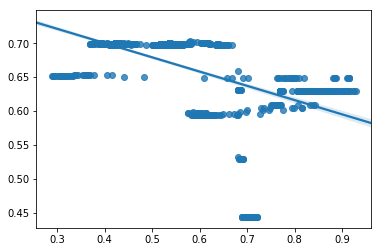

In [43]:
sns.regplot(tpt_pred_dist, tpt_rec_dist)

## compare prediction content to episode 2 content (WIP)

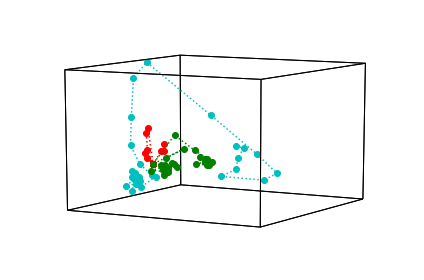

In [52]:
hyp.plot([avg_participant_events['prediction']]+[episode_events['atlep2']]+[avg_participant_events['atlep2']], fmt=
         ['ro:','co:','go:'])

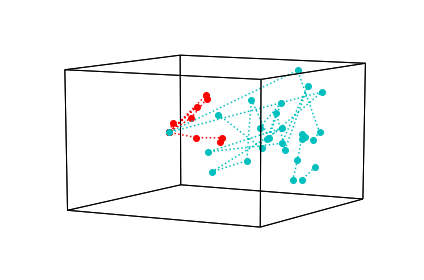

In [53]:
hyp.plot([avg_participant_events['prediction']]+[avg_participant_events['atlep2']], fmt=
         ['ro:','co:'])

## does prediction content influence event memory

In [80]:
for ep2_event in atlep2_events:
    
    # find maximally correlated prediction event
    p_event_maxcorr = np.max(1-cdist([ep2_event], avg_pred_events, 'correlation'))
    
    # relate to distance to average recall event for that episode event
    mindist_rec_ev = np.min(cdist())

0.5698048203500193
0.5279125352778792
0.5107823142671394
0.41153395236511026
0.02152456682799797
-0.029637087106140214
-0.025064001325265206
-0.029388441446564606
0.22413827347829018
0.7987471506766661
0.7065511447123237
0.45132870092077115
0.027782801275818447
-0.028441648890813243
-0.02675088169964268
-0.029978428155319037
-0.02425961721610137
-0.03306295358271538
-0.030856218306867023
-0.026665228052402234
-0.030425924102416957
-0.02281299739539122
0.16956054409416754
0.6527949727622029
0.07550942480589373
-0.021908583898202494
-0.0240323956436872


In [90]:
np.min(cdist([ep2_event], avg_atlep2_rec_events))

0.5128705345890805

## does how an episode 2 event was predicted affect how it was later remembered?

In [45]:
# # NOTE: lots of issues with repeat event matches, using first occurence of event mappings

# prediction_event_effects = pd.DataFrame(index=list(id_maps.keys()), 
#                                         columns=['pred_ep_disp','pred_ep_direc','ep_rec_disp','ep_rec_direc'])
# # for each subject and their atlep2 recall events
# for turkid2, events in participant_events['atlep2']:
#     # get their across-session ID and session 1 ID
#     sid, turkid1 = next((sid, id_maps[sid]['session 1']) for sid in id_maps.keys() 
#                         if id_maps[sid]['session 2'] == turkid2)

#     # get the atlep2 events they predicted and those they remembered later
#     sub_pred_evs = next(p_evs for tid, p_evs in pred_events if tid == turkid1)
#     sub_atlep2_rec_evs = next(r_evs for tid, r_evs in atlep2_rec_events if tid == turkid2)
    
#     # get their prediction/atlep2 and atlep2/recall event mappings
#     sub_pred_mappings = np.unique(next(ms for tid, ms in event_mappings['prediction'] if tid == turkid1))
#     sub_atlep2_rec_mappings = np.unique(next(ms for tid, ms in event_mappings['atlep2'] if tid == turkid2))

#     # index mask for predicted events later recalled
#     inboth_ix = sub_pred_mappings[np.isin(sub_pred_mappings, sub_atlep2_rec_mappings)]
    
#     # if any events were both predicted and recalled
#     if any(inboth_ix):
        
#         # displacement vector and between each predicted atlep2 event and its prediction, and unit vector
#         pred_ep_disp = sub_pred_evs[np.where(np.isin(sub_pred_mappings, inboth_ix))] - atlep2_events[inboth_ix]
#         pred_ep_direc = pred_ep_disp / np.absolute(pred_ep_disp)

#         # find the displacement vector between the episode event and their later recall of it, and unit vector
#         ep_rec_disp = atlep2_events[inboth_ix] - sub_atlep2_rec_evs[np.where(np.isin(sub_atlep2_rec_mappings, inboth_ix))]
#         ep_rec_direc = ep_rec_disp / np.absolute(ep_rec_disp)


#         prediction_event_effects.loc[sid] = [pred_ep_disp, pred_ep_direc, ep_rec_disp, ep_rec_direc]
        
# prediction_event_effects.dropna(inplace=True)



In [46]:
for row, data in prediction_event_effects.iterrows():
    prediction_event_effects.at[row, 'dist_corr'] = np.diag(1-cdist(np.atleast_2d(data['pred_ep_disp']), 
        np.atleast_2d(data['ep_rec_disp']), 'correlation')).mean()

    prediction_event_effects.at[row, 'direc_corr'] = np.diag(1-cdist(np.atleast_2d(data['pred_ep_direc']), 
        np.atleast_2d(data['ep_rec_direc']), 'correlation')).mean()

In [47]:
prediction_event_effects

,pred_ep_disp,pred_ep_direc,ep_rec_disp,ep_rec_direc,dist_corr,direc_corr
MD-101218-A-01,"[[0.00023888355217018147, 0.000238883552170181...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.0001641593345574562, -0.00016415933455745...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.776191,-0.812320
MD-101218-A-02,"[[0.0001762009443399464, 0.0001762009443399464...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.000494955056217593, -0.000494955056217593...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.843686,-1.000000
MD-101218-A-04,"[[0.00019874055421853357, 0.000198740554218533...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.00013042539102127145, -0.0001304253910212...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.827754,-1.000000
MD-101318-A-04,"[[0.00014439194396163486, 0.000144391943961634...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.00010824292415514188, -0.0001082429241551...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.788160,-0.739583
MD-102118-A-01,"[[0.00014359247522053903, 0.000143592475220539...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.00025975979104876456, -0.0002597597910487...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.807773,-0.696799
MD-102218-A-05,"[[0.00015482580679417477, 0.000154825806794174...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.0001776159200589829, -0.00017761592005898...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.798623,-0.775952
MD-020119-A-04,"[[0.00018957120804598726, 0.000189571208045987...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.0001417378618496004, -0.00014173786184960...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.759362,-1.000000
MD-021519-A-01,"[[0.00034269915197726245, 0.000342699151977262...","[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...","[[-0.00013414766290430641, -0.0001341476629043...","[[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1...",-0.775415,-0.489796
